#Logistička funkcija

NameError: name 'probs' is not defined

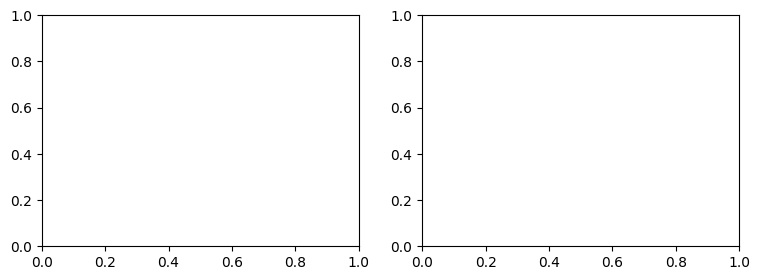

In [1]:
import matplotlib.pyplot as plt

def helper(ax,x,y,x_name,y_name):
  ax.plot(x,y, 'r--o')
  ax.set_xlabel(x_name)
  ax.set_ylabel(y_name)

fig, (ax0, ax1) = plt.subplots(1,2, figsize=(9,3))
helper(ax0, probs, log_odds, 'vjerojatnost', 'log-izgledi')
helper(ax1, log_odds, probs, 'log-izgledi', 'vjerojatnost')

In [2]:
from sklearn import linear_model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [6]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

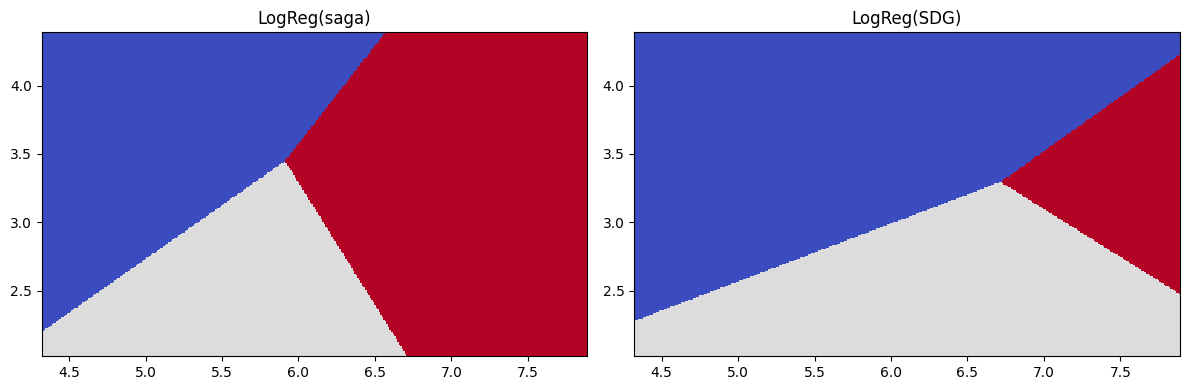

In [9]:
iris = load_iris()
LogReg = linear_model.LogisticRegression
SGD = linear_model.SGDClassifier

logreg_class = {
    'LogReg(saga)': LogReg(solver="saga", max_iter=1000),
    'LogReg(SDG)': SGD(loss='log_loss', max_iter=1000)
}

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes = axes.flat
for (name, model), ax in zip(logreg_class.items(), axes):
  plot_boundary(ax, iris.data, iris.target, model, (0,1))
  ax.set_title(name)
plt.tight_layout()



# Diskrimantna analiza

In [10]:
import pandas as pd


In [11]:
data = pd.DataFrame({'X':[1,3,6],
                     'Y':[1,6,3],
                     'Z':[10,5,1]
                     })

data.index.name = 'Primjeri'
display(data)
display(data.cov())

,X,Y,Z
Primjeri,,,
0,1,1,10
1,3,6,5
2,6,3,1


,X,Y,Z
X,6.333333,1.833333,-11.166667
Y,1.833333,6.333333,-5.166667
Z,-11.166667,-5.166667,20.333333


Text(0, 0.5, 'values')

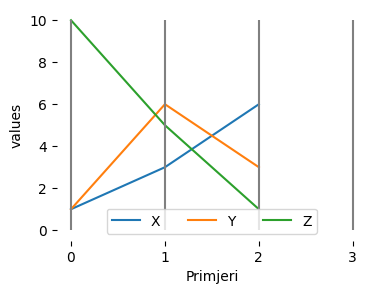

In [12]:
import matplotlib.pyplot as plt

fix, ax = plt.subplots(1,1,  figsize=(4,3))
data.plot(ax=ax)
ax.vlines([0,1,2,3], 0, 10, colors=".5")
ax.legend(loc='lower center', ncol=3)
plt.box(False)
ax.set_xticks([0,1,2,3])
ax.set_ylabel("values")

In [13]:
from sklearn import discriminant_analysis, naive_bayes, metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn import model_selection as skms

Text(0.5, 20.222222222222214, 'Predicted')

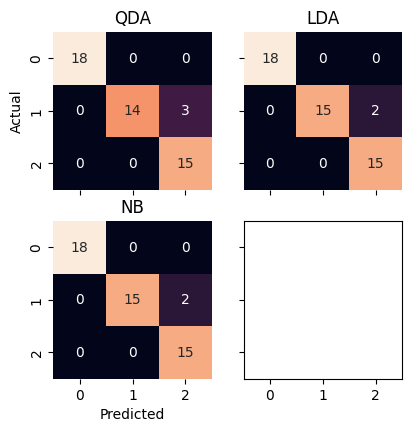

In [14]:
gda = discriminant_analysis.QuadraticDiscriminantAnalysis()
lda = discriminant_analysis.LinearDiscriminantAnalysis()
nb = naive_bayes.GaussianNB()

iris = datasets.load_iris()
tts = skms.train_test_split(iris.data, iris.target, test_size=0.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = tts

da_methods = [gda, lda, nb]
names = ["QDA", "LDA", "NB"]

fig, axes = plt.subplots(2,2, figsize=(4.5, 4.5), sharex=True, sharey = True)
for ax, model, name in zip(axes.flat, da_methods, names):
    preds = (model.fit(iris_train_ftrs, iris_train_tgt)
      .predict(iris_test_ftrs))
    cm = metrics.confusion_matrix(iris_test_tgt, preds)

    sns.heatmap(cm, annot=True, cbar=False, ax=ax)
    ax.set_title(name)

axes[0,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

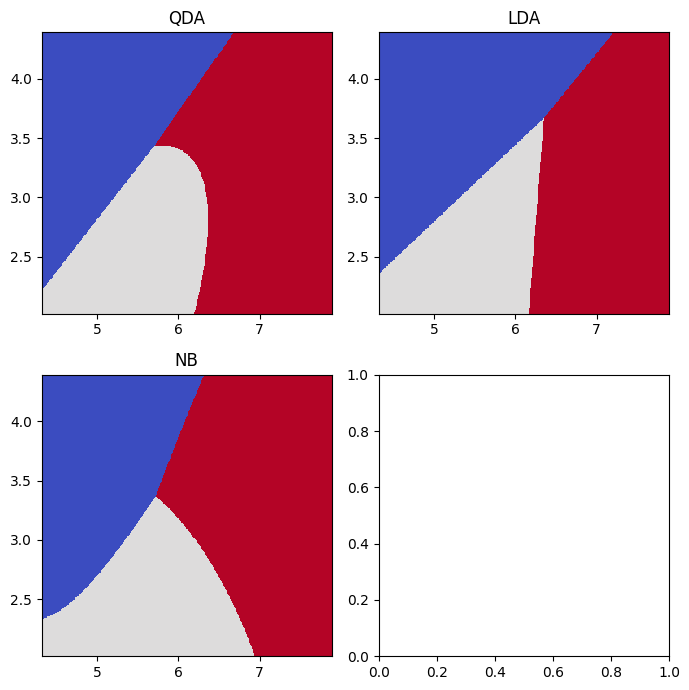

In [17]:
fig, axes = plt.subplots(2,2, figsize=(7,7))
axes = axes.flat

iris = load_iris()
for model, ax, name in zip(da_methods, axes, names):

    plot_boundary(ax, iris.data, iris.target, model, [0,1])
    ax.set_title(name)
plt.tight_layout()

Oblik (8, 8)


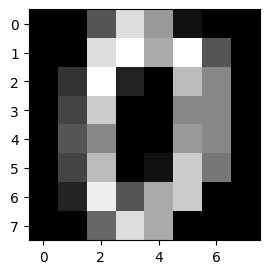

In [23]:
digits = datasets.load_digits()
print("Oblik", digits.images[0].shape)
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[0], cmap="gray")


In [24]:
from sklearn import discriminant_analysis, naive_bayes, metrics
from sklearn import linear_model, svm, tree, neighbors, dummy
from sklearn import datasets
from sklearn import model_selection as skms

In [30]:
classifier_parade = {
    'LogReg(1)': linear_model.LogisticRegression(max_iter=1000),
    'LogReg(2)': linear_model.SGDClassifier(loss='log_loss', max_iter=1000),
    'ODA': discriminant_analysis.QuadraticDiscriminantAnalysis(),
    'LDA': discriminant_analysis.LinearDiscriminantAnalysis(),
    'NB': naive_bayes.GaussianNB(),
    'SVC(1)': svm.SVC(kernel='linear'),
    'SVC(2)': svm.LinearSVC(),
    'DTC': tree.DecisionTreeClassifier(),
    'KNN_5': neighbors.KNeighborsClassifier(),
    'KNN_10': neighbors.KNeighborsClassifier(n_neighbors=10)
}

baseline = dummy.DummyClassifier(strategy='uniform')
base_score = skms.cross_val_score(baseline, digits.data, digits.target==1, cv=10, scoring='average_precision')

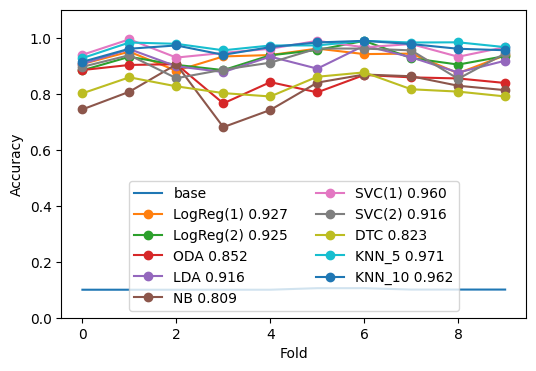

In [31]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(base_score, label='base')
markers = ['o']
for name, model in classifier_parade.items():
    cv_scores = skms.cross_val_score(model, digits.data, digits.target, cv=10, scoring='f1_macro', n_jobs=-1) # all CPUs
    my_lbl = "{} {:.3f}".format(name, cv_scores.mean())
    ax.plot(cv_scores, label=my_lbl, marker=next(iter(markers))) # Use iter(markers) to cycle through markers
ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower center', ncol=2)

In [33]:
from PIL import Image, ImageOps
import numpy as np
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression

In [ ]:
digits = load_digits()
X, y = digits.data, digits.target
clf = LogisticRegression(max_iter=5000)
clf.fit(X, y)

image = Image.open("broj.png").convert("L") #metoda za nijanse sive
im = image.resize((8,8), Image.BILINEAR)
plt.figure(figsize=(3, 3))
plt.imshow(im, cmap="gray")

arr = np.asarray(im).astype(np.float32) / 255.0
x_norm = (arr * 16.0).reshape(1, -1)

x_norm = (arr*16.0).reshape(1,-1)
print(x_norm)

proba_norm = clf.predict_proba(x_norm)[0]
print(proba_norm)
pred_norm = np.argmax(proba_norm)
final = int(pred_norm)
final_conf = float(proba_norm[pred_norm])

print(final)
print(final_conf)
for digit, p in enumerate(proba_norm):
  print(f"{digit}:{p:.4f}")